In [4]:
# ============================================================================
# Python Visualization Code for 2-Group DESeq2 Analysis
# ============================================================================
# 
# This script generates:
#   1. PCA plot (using VST-transformed data from DESeq2)
#   2. Gene list comparison (Venn diagram / UpSet plot)
#
# Prerequisites: Run DESeq2_2group_newly_eclosed.R first to generate input files
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from adjustText import adjust_text
from sklearn.decomposition import PCA

# Set style
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300



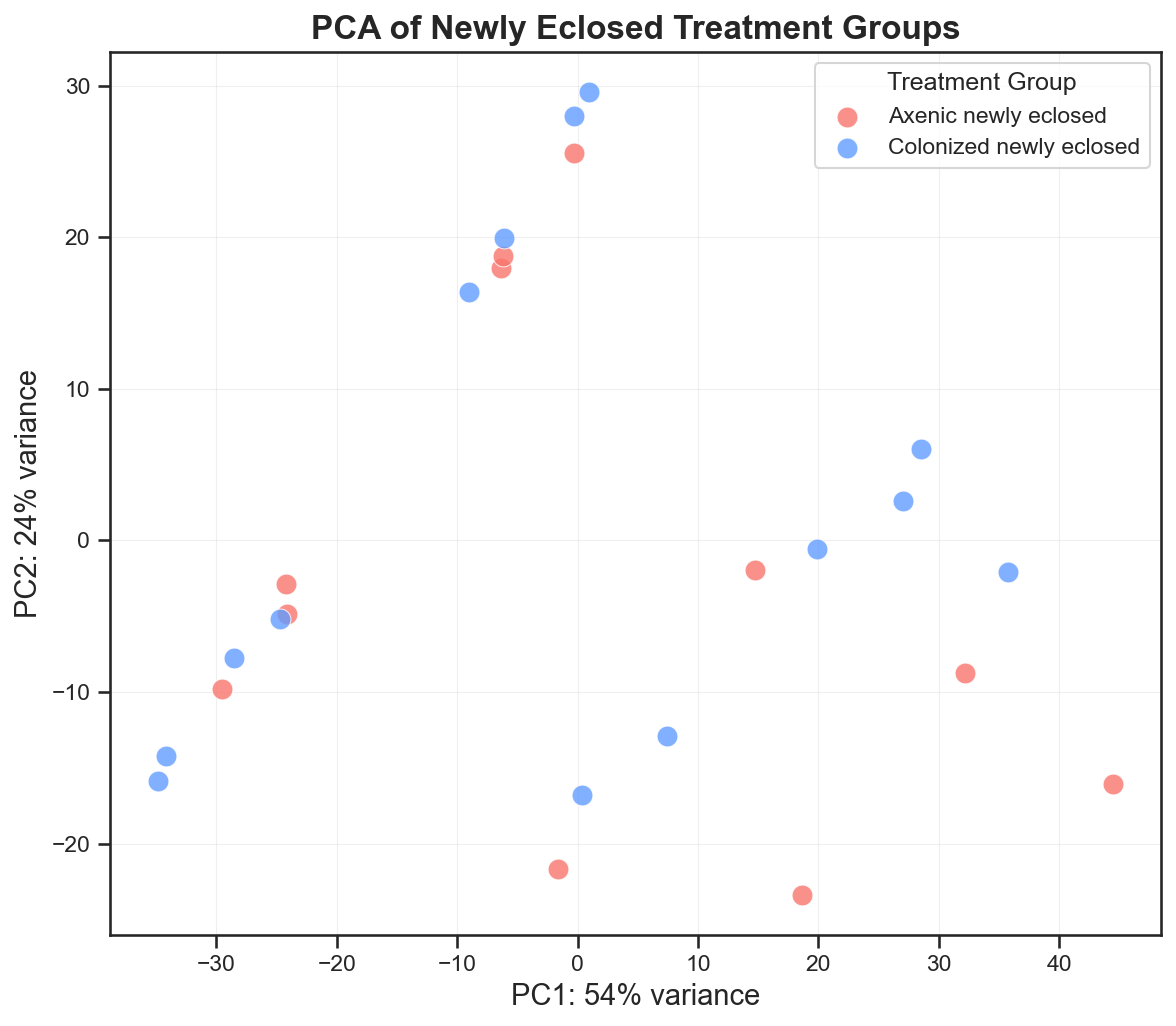

Variance explained: PC1=53.7%, PC2=24.3%


In [9]:
def plot_pca(pca_file, vst_file, output_prefix):
    """
    Create PCA plot from DESeq2 output with correct variance percentages.

    Parameters:
    pca_file: Path to pca_data.csv from R script (DESeq2 plotPCA output)
    vst_file: Path to vst_counts.csv from R script (VST-transformed counts)
    output_prefix: Prefix for output files
    """
    # Load PCA coordinates from DESeq2
    pca_df = pd.read_csv(pca_file)

    # Load VST data to calculate variance explained
    vst_df = pd.read_csv(vst_file)
    sample_cols = [c for c in vst_df.columns if c not in ['gene_id', 'gene_name']]
    vst_matrix = vst_df[sample_cols].T

    # Calculate variance explained from VST data
    pca_calc = PCA()
    pca_calc.fit(vst_matrix)
    var_explained = pca_calc.explained_variance_ratio_ * 100
    pc1_var = var_explained[0]
    pc2_var = var_explained[1]

    # Map technical names to descriptive labels
    LABEL_MAP = {
        'A_inoR': 'Colonized newly eclosed', 
        'B_conR': 'Axenic newly eclosed'
    }

    # Colors matching original plot
    COLORS = {
        'B_conR': '#F8766D',      # Red/coral - Colonized newly eclosed
        'A_inoR': '#619CFF'      # Blue - Axenic newly eclosed
    }

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 7))

    # Plot each group with descriptive labels
    for group in ['B_conR', 'A_inoR']:  # Order for legend
        data = pca_df[pca_df['condition'] == group]
        ax.scatter(data['PC1'], data['PC2'], 
                   c=COLORS[group], 
                   label=LABEL_MAP[group],
                   s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

    # Labels with variance percentages
    ax.set_xlabel(f'PC1: {pc1_var:.0f}% variance', fontsize=14)
    ax.set_ylabel(f'PC2: {pc2_var:.0f}% variance', fontsize=14)
    ax.set_title('PCA of Newly Eclosed Treatment Groups', fontsize=16, fontweight='bold')
    ax.legend(title='Treatment Group', loc='best', fontsize=11, title_fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    plt.tight_layout()
    # plt.savefig(f'{output_prefix}_PCA.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Variance explained: PC1={pc1_var:.1f}%, PC2={pc2_var:.1f}%")

if __name__ == "__main__":
    # Set paths
    results_dir = "DESeq2_3group_results"
    output_prefix = "3group_analysis"

    # 1. PCA Plot
    plot_pca('pca_data_newly.csv', 'vst_counts_newly.csv', output_prefix)

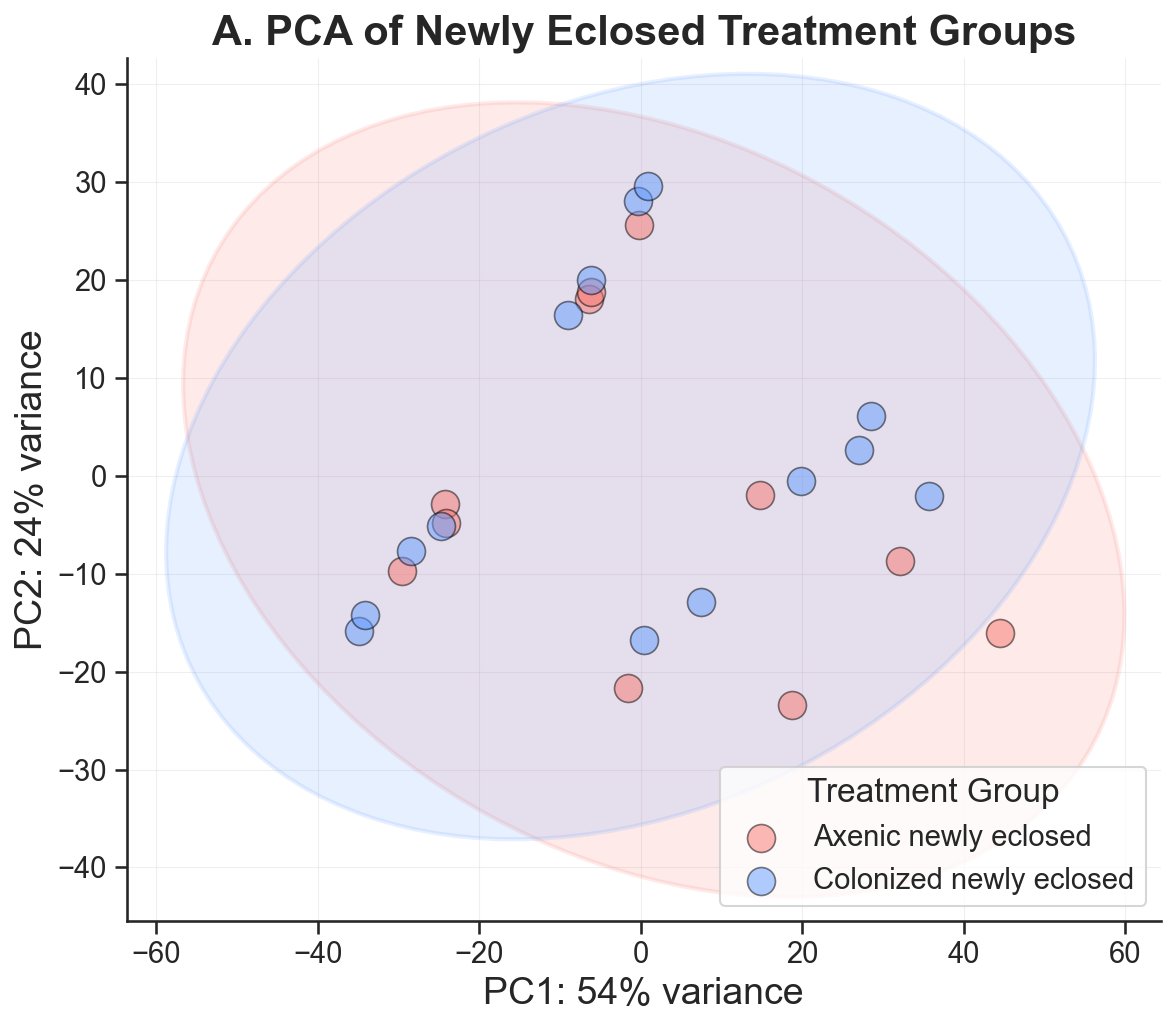

Variance explained: PC1=53.7%, PC2=24.3%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'DejaVu Sans']
matplotlib.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from scipy import stats

sns.set_theme(style="ticks")

# =============================================================================
# FUNCTION: Add 95% Confidence Ellipse
# =============================================================================
def add_confidence_ellipse(ax, x, y, color, **kwargs):
    if len(x) < 3:
        return

    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    chi2_val = stats.chi2.ppf(0.95, 2)

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width = 2 * np.sqrt(eigenvalues[0] * chi2_val)
    height = 2 * np.sqrt(eigenvalues[1] * chi2_val)

    ellipse = Ellipse(
        xy=(mean_x, mean_y),
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        alpha=0.15,
        edgecolor=color,
        linewidth=2,
        **kwargs
    )
    ax.add_patch(ellipse)
    return ellipse

# =============================================================================
# FUNCTION: PCA PLOT FOR NEWLY ECLOSED GROUP
# =============================================================================
def plot_newly_eclosed_pca(pca_file, vst_file, output_prefix):
    """
    Create PCA plot for newly eclosed samples only.
    """

    # Load PCA coordinates
    pca_df = pd.read_csv(pca_file)

    # Load VST data for variance explained
    vst_df = pd.read_csv(vst_file)
    sample_cols = [c for c in vst_df.columns if c not in ['gene_id', 'gene_name']]
    vst_matrix = vst_df[sample_cols].T

    # Calculate variance explained
    pca_calc = PCA()
    pca_calc.fit(vst_matrix)
    var_explained = pca_calc.explained_variance_ratio_ * 100
    pc1_var = var_explained[0]
    pc2_var = var_explained[1]

    # Labels and colors
    LABEL_MAP = {
        'A_inoR': 'Colonized newly eclosed', 
        'B_conR': 'Axenic newly eclosed'
    }

    COLORS = {
        'B_conR': '#F8766D',  # coral/red
        'A_inoR': '#619CFF'   # blue
    }

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 7))

    # Plot each group
    for group in ['B_conR', 'A_inoR']:
        data = pca_df[pca_df['condition'] == group]

        if len(data) == 0:
            continue

        ax.scatter(
            data['PC1'],
            data['PC2'],
            c=COLORS[group],
            label=LABEL_MAP[group],
            s=180,
            alpha=0.5,
            edgecolors='black',
            linewidth=0.8,
            zorder=3
        )

        add_confidence_ellipse(ax, data['PC1'].values, data['PC2'].values, COLORS[group])

    # Styling
    ax.set_xlabel(f'PC1: {pc1_var:.0f}% variance', fontsize=18)
    ax.set_ylabel(f'PC2: {pc2_var:.0f}% variance', fontsize=18)
    ax.set_title('A. PCA of Newly Eclosed Treatment Groups', fontsize=20, fontweight='bold')
    ax.legend(title='Treatment Group', fontsize=14, title_fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    sns.despine(ax=ax)

    plt.tight_layout()
    # plt.savefig(f'{output_prefix}_newly_eclosed_PCA.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Variance explained: PC1={pc1_var:.1f}%, PC2={pc2_var:.1f}%")

# =============================================================================
# USAGE
# =============================================================================
if __name__ == "__main__":
    results_dir = "DESeq2_3group_results"
    output_prefix = "3group_analysis"

    plot_newly_eclosed_pca('pca_data_newly.csv', 'vst_counts_newly.csv', output_prefix)